Importar Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Manipulção de dados (DataFrames)
import pandas as pd
#Operações numericas e vetoriais
import numpy as np
#Visualizações básicas e avançadas
import matplotlib.pyplot as plt
#Gráficos estátisticos com estilo
import seaborn as sns


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from google.colab import files
uploaded = files.upload()

Saving dados_venda_empresa1.csv.csv to dados_venda_empresa1.csv.csv


In [5]:
#importando os dados
df = pd.read_csv('dados_venda_empresa1.csv.csv')

In [6]:
#Ver as primeiras linhas do data frame
print(df.head())

   data_venda          nome_cliente estado    nome_produto    categoria  \
0  2025-05-11   Dra, Mariana da Paz     BA           Leite    Alimentos   
1  2025-03-14       Marcela Rezende     BA          Feijão    Alimentos   
2  2025-04-18    Srta, Brenda Cunha     BA   Quebra-Cabeça   Brinquedos   
3  2025-02-09  Maria Clara Caldeira     BA  Fone de Ouvido  Eletrônicos   
4  2025-04-10   João Felipe Cardoso     BA        Carrinho   Brinquedos   

   quantidade preco_unitario  total_venda  quantidade_estoque  \
0           9       1.610,73     14496.57                 116   
1           7       2.406,94     16848.58                 131   
2           1       2.192,52      2192.52                 224   
3           2       2.008,93      4017.86                 201   
4           8         624,63      4997.04                 170   

  localizacao_estoque   ano  mes  dia  dia da semana  
0            C3-A2-B2  2025    5   11              1  
1            B2-A1-C2  2025    3   14           

Conhecer os nossos dados

In [7]:
print(f"\nSeu dataset tem {df.shape[0]} linhas e {df.shape[1]} colunas")


Seu dataset tem 200 linhas e 14 colunas


In [8]:
#Nome das colunas
print(df.columns)

Index(['data_venda', 'nome_cliente', 'estado', 'nome_produto', 'categoria',
       'quantidade', 'preco_unitario', 'total_venda', 'quantidade_estoque',
       'localizacao_estoque', 'ano', 'mes', 'dia', 'dia da semana'],
      dtype='object')


In [9]:
#Nome das colunas
print(df.columns.tolist())

['data_venda', 'nome_cliente', 'estado', 'nome_produto', 'categoria', 'quantidade', 'preco_unitario', 'total_venda', 'quantidade_estoque', 'localizacao_estoque', 'ano', 'mes', 'dia', 'dia da semana']


In [10]:
#Verificar se os dados estão corretos
dados_faltantes = df.isnull().sum()
print(dados_faltantes)

data_venda             0
nome_cliente           0
estado                 0
nome_produto           0
categoria              0
quantidade             0
preco_unitario         0
total_venda            0
quantidade_estoque     0
localizacao_estoque    0
ano                    0
mes                    0
dia                    0
dia da semana          0
dtype: int64


In [11]:
#Resumo Estatisticos
print(df.describe())

       quantidade  total_venda  quantidade_estoque          ano         mes  \
count  200.000000    200.00000          200.000000   200.000000  200.000000   
mean     5.805000   8412.64690          162.870000  2024.850000    4.450000   
std      2.927426   6864.71105           81.097392     0.357967    3.488315   
min      1.000000     81.18000           11.000000  2024.000000    1.000000   
25%      3.000000   2630.60000           97.750000  2025.000000    2.000000   
50%      6.000000   6392.92000          169.000000  2025.000000    4.000000   
75%      8.000000  12998.90250          233.250000  2025.000000    5.000000   
max     10.000000  26662.59000          298.000000  2025.000000   12.000000   

              dia  dia da semana  
count  200.000000      200.00000  
mean    16.405000        4.05000  
std      8.609973        2.18894  
min      1.000000        1.00000  
25%     10.000000        2.00000  
50%     17.000000        4.00000  
75%     24.000000        6.00000  
max     

In [12]:
#Valores zerados em colunas numericas
df[['quantidade', 'preco_unitario', 'total_venda']].eq(0).sum()

,0
quantidade,0
preco_unitario,0
total_venda,0


Operações básicas no Python

In [13]:
#Somar uma coluna
print(df['total_venda'].sum())

1682529.3800000001


In [42]:
# Converter 'preco_unitario' para numérico antes de calcular 'total_venda'
df['preco_unitario'] = df['preco_unitario'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
df['preco_unitario'] = pd.to_numeric(df['preco_unitario'])

# Recalcular 'total_venda'
df['total_venda'] = df['quantidade'] * df['preco_unitario']

print("Tipo de dados da coluna 'preco_unitario' após conversão:")
print(df['preco_unitario'].dtype)
print("Valores 'preco_unitario' após conversão:")
print(df['preco_unitario'].head())
print("\nTipo de dados da coluna 'total_venda' após recalculado:")
print(df['total_venda'].dtype)
print("Valores 'total_venda' após recalculado:")
print(df['total_venda'].head())

Tipo de dados da coluna 'preco_unitario' após conversão:
float64
Valores 'preco_unitario' após conversão:
0    1610.73
1    2406.94
2    2192.52
3    2008.93
4     624.63
Name: preco_unitario, dtype: float64

Tipo de dados da coluna 'total_venda' após recalculado:
float64
Valores 'total_venda' após recalculado:
0    14496.57
1    16848.58
2     2192.52
3     4017.86
4     4997.04
Name: total_venda, dtype: float64


In [40]:
# Converter a coluna 'total_venda' para string e substituir ',' por '.'
df['total_venda'] = df['total_venda'].astype(str).str.replace(',', '.')
print("Valores 'total_venda' após substituição de vírgula por ponto:")
print(df['total_venda'].head())

Valores 'total_venda' após substituição de vírgula por ponto:
0    1.610.731.610.731.610.731.610.731.610.731.610....
1    2.406.942.406.942.406.942.406.942.406.942.406....
2                                             2.192.52
3                                     2.008.932.008.93
4     624.63624.63624.63624.63624.63624.63624.63624.63
Name: total_venda, dtype: object


In [41]:
# Converter a coluna 'total_venda' para tipo numérico (float)
df['total_venda'] = pd.to_numeric(df['total_venda'])
print("Tipo de dados da coluna 'total_venda' após conversão:")
print(df['total_venda'].dtype)
print("Valores 'total_venda' após conversão para numérico:")
print(df['total_venda'].head())

ValueError: Unable to parse string "1.610.731.610.731.610.731.610.731.610.731.610.731.610.731.610.731.610.73" at position 0

In [15]:
#Média da coluna quantidade
print(df['quantidade'].mean())

5.805


Filtros

In [16]:
#Filtrar itens da categoria Eletrônicos
print(df[df['categoria'] == 'Eletrônicos'])


     data_venda              nome_cliente estado    nome_produto    categoria  \
3    2025-02-09      Maria Clara Caldeira     BA  Fone de Ouvido  Eletrônicos   
5    2025-04-04             Alana Peixoto     BA  Fone de Ouvido  Eletrônicos   
8    2024-12-21                Davi Silva     BA          Tablet  Eletrônicos   
15   2025-04-10          Vicente Teixeira     BA  Fone de Ouvido  Eletrônicos   
19   2025-01-13             Daniela Rocha     BA        Notebook  Eletrônicos   
20   2025-03-16           Nathan Teixeira     BA          Tablet  Eletrônicos   
22   2024-12-19      Sr, Benício da Cunha     BA         Monitor  Eletrônicos   
25   2025-01-22               Ian Pereira     BA  Fone de Ouvido  Eletrônicos   
35   2024-12-27            Thales Pereira     BA  Fone de Ouvido  Eletrônicos   
43   2025-05-27        Davi Lucca Cardoso     MG      Smartphone  Eletrônicos   
44   2024-12-22         Emanuelly Correia     MG      Smartphone  Eletrônicos   
49   2025-01-03     Luiz Hen

In [17]:
#filtro compostos ou combinados
print(df[(df['categoria'] == 'Eletrônicos') & (df['quantidade'] > 3)])

     data_venda              nome_cliente estado    nome_produto    categoria  \
5    2025-04-04             Alana Peixoto     BA  Fone de Ouvido  Eletrônicos   
8    2024-12-21                Davi Silva     BA          Tablet  Eletrônicos   
15   2025-04-10          Vicente Teixeira     BA  Fone de Ouvido  Eletrônicos   
20   2025-03-16           Nathan Teixeira     BA          Tablet  Eletrônicos   
22   2024-12-19      Sr, Benício da Cunha     BA         Monitor  Eletrônicos   
25   2025-01-22               Ian Pereira     BA  Fone de Ouvido  Eletrônicos   
35   2024-12-27            Thales Pereira     BA  Fone de Ouvido  Eletrônicos   
49   2025-01-03     Luiz Henrique Pereira     MG      Smartphone  Eletrônicos   
59   2025-04-04      Dra, Catarina Castro     PE          Tablet  Eletrônicos   
61   2025-03-07               Clara Viana     PE         Monitor  Eletrônicos   
67   2025-05-28      Luiz Gustavo Freitas     PE         Monitor  Eletrônicos   
79   2025-05-24            L

Agrupamentos

In [18]:
#Media quantidade vendida por categoria
print(df.groupby('categoria')['quantidade'].mean())

categoria
Alimentos      5.682927
Brinquedos     5.590909
Eletrônicos    6.694444
Móveis         5.361111
Vestuário      5.767442
Name: quantidade, dtype: float64


In [19]:
#Soma quantidade vendida por categoria
print(df.groupby('categoria')['quantidade'].sum())

categoria
Alimentos      233
Brinquedos     246
Eletrônicos    241
Móveis         193
Vestuário      248
Name: quantidade, dtype: int64


In [20]:
#Multiplas estatisticas por categoria
print(df.groupby('categoria')['quantidade'].agg(['mean', 'sum', 'count', 'max', 'min']))

                 mean  sum  count  max  min
categoria                                  
Alimentos    5.682927  233     41   10    1
Brinquedos   5.590909  246     44   10    1
Eletrônicos  6.694444  241     36   10    1
Móveis       5.361111  193     36   10    1
Vestuário    5.767442  248     43   10    1


Gráficos

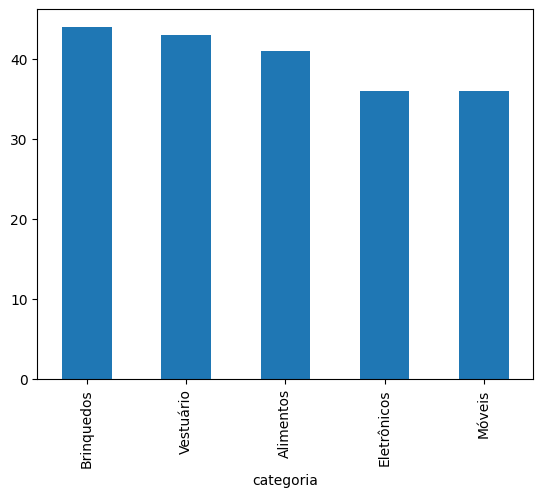

In [23]:
#grafico simples de barras
df['categoria'].value_counts().plot(kind='bar')
plt.show()

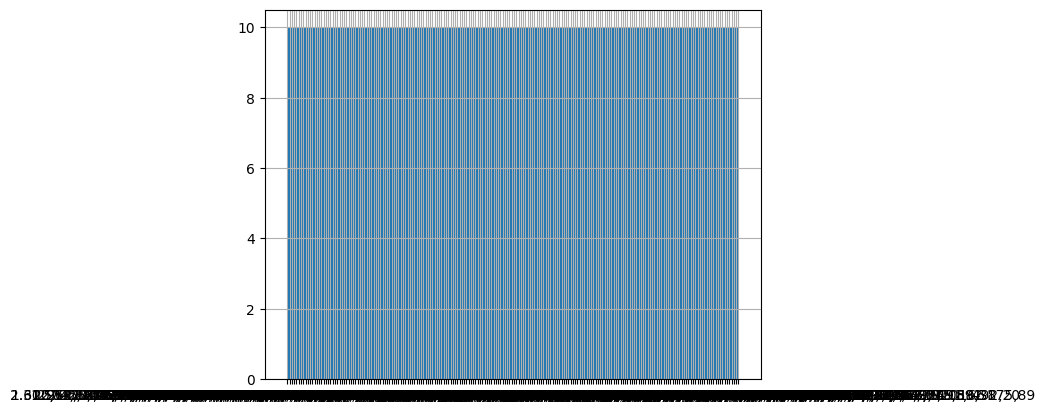

In [25]:
#histrograma de distribuicao dos valores de venda "total venda"
df['total_venda'].hist(bins=20)
plt.show()

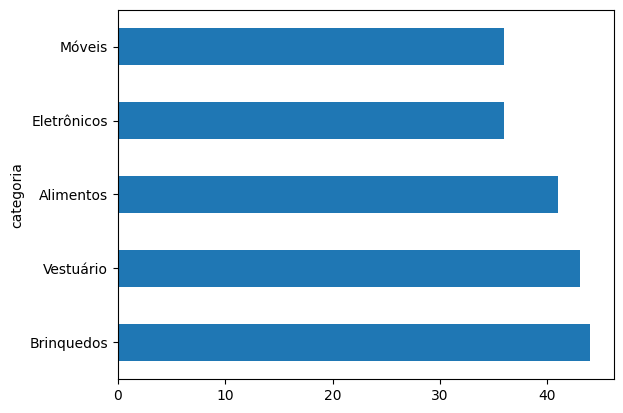

In [28]:
#graficos com barras horizontais com total_venda
df['categoria'].value_counts().plot(kind='barh')
plt.show()

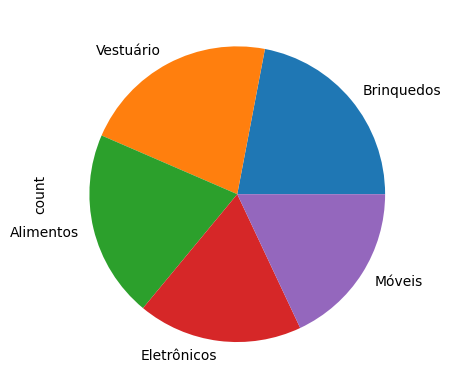

In [29]:
#graficos com barras horizontais com total_venda
df['categoria'].value_counts().plot(kind='pie')
plt.show()

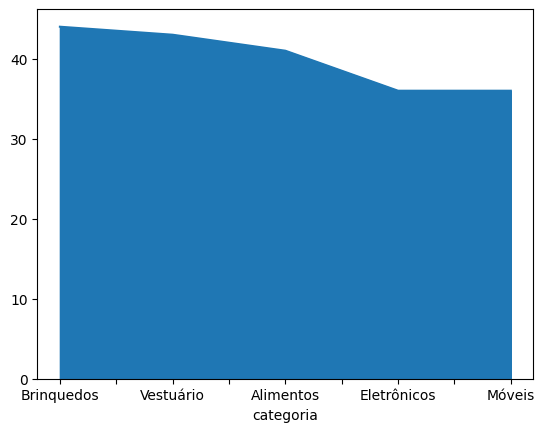

In [30]:
#graficos com area com total_venda
df['categoria'].value_counts().plot(kind='area')
plt.show()

Criar uma coluna nova VIP ou NÃO VIP

In [43]:
#Criar uma nova coluna status do cliente
df['STATUS'] = np.where(df['total_venda'] > 1000, 'VIP', 'NÃO VIP')

In [44]:
#vendo o head do data set
print(df.head())

   data_venda          nome_cliente estado    nome_produto    categoria  \
0  2025-05-11   Dra, Mariana da Paz     BA           Leite    Alimentos   
1  2025-03-14       Marcela Rezende     BA          Feijão    Alimentos   
2  2025-04-18    Srta, Brenda Cunha     BA   Quebra-Cabeça   Brinquedos   
3  2025-02-09  Maria Clara Caldeira     BA  Fone de Ouvido  Eletrônicos   
4  2025-04-10   João Felipe Cardoso     BA        Carrinho   Brinquedos   

   quantidade  preco_unitario  total_venda  quantidade_estoque  \
0           9         1610.73     14496.57                 116   
1           7         2406.94     16848.58                 131   
2           1         2192.52      2192.52                 224   
3           2         2008.93      4017.86                 201   
4           8          624.63      4997.04                 170   

  localizacao_estoque   ano  mes  dia  dia da semana STATUS  
0            C3-A2-B2  2025    5   11              1    VIP  
1            B2-A1-C2  2025 

Trabalhando com datas


In [47]:
#Garantir que as informações de data estão no formato dataline
df['data_venda'] = pd.to_datetime(df['data_venda'])

In [48]:
#extrair as informações de data
df['ano'] = df['data_venda'].dt.year
df['mes'] = df['data_venda'].dt.month
df['dia'] = df['data_venda'].dt.day

Analisando as oportunidades

In [49]:
#qual o total de vendas do periodo
print(df['total_venda'].sum())

1682529.3800000001


In [50]:
#qual é a média das vendas
print(df['total_venda'].mean())

8412.6469


In [51]:
#qual categoria vende mais
print(df.groupby('categoria')['total_venda'].sum())

categoria
Alimentos      378777.27
Brinquedos     331006.07
Eletrônicos    322217.60
Móveis         286853.41
Vestuário      363675.03
Name: total_venda, dtype: float64


In [52]:
#qual é a maior venda individual?
print(df['total_venda'].max())

26662.590000000004


Analise final

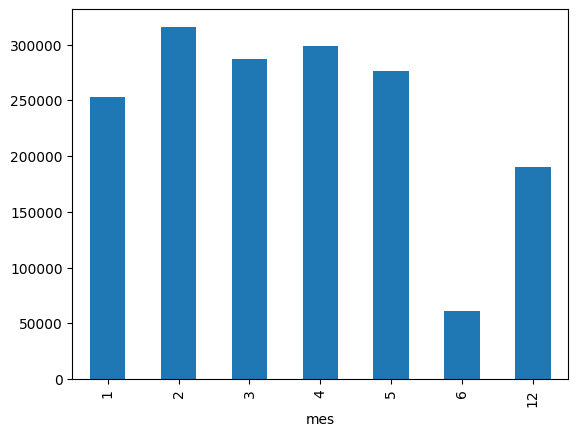

In [53]:
#grafico vendas totais por mes
df.groupby('mes')['total_venda'].sum().plot(kind='bar')
plt.show()

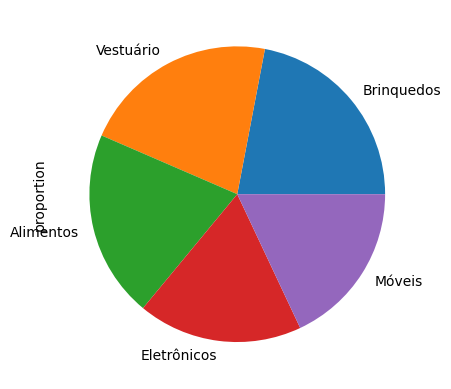

In [54]:
#grafico de pizza do percentual de vendas por categoria
df['categoria'].value_counts(normalize=True).plot(kind='pie')
plt.show()

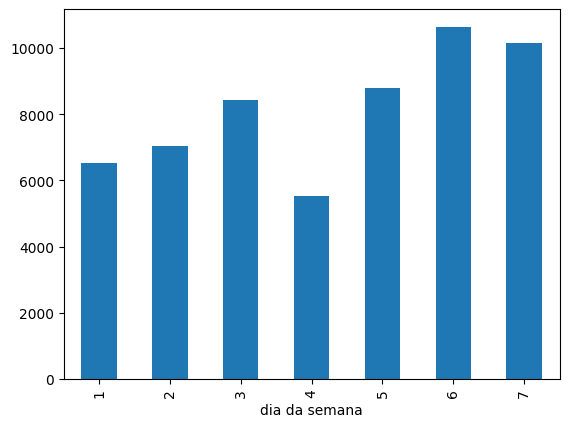

In [56]:
#grafico de vendas medias por dia da semana
df.groupby('dia da semana')['total_venda'].mean().plot(kind='bar')
plt.show()

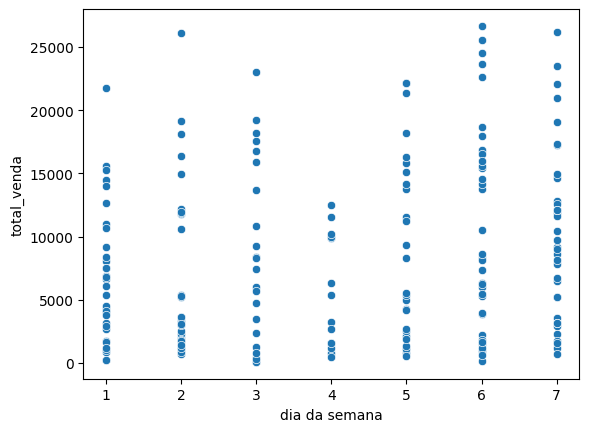

In [57]:
# grafico de dispercao do dia da semana com o total de vendas
sns.scatterplot(x='dia da semana', y='total_venda', data=df)
plt.show()

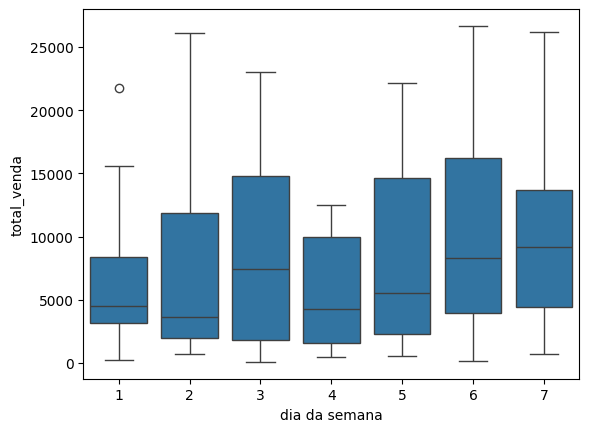

In [58]:
#boxploat da distribuição de vendas por dia
sns.boxplot(x='dia da semana', y='total_venda', data=df)
plt.show()

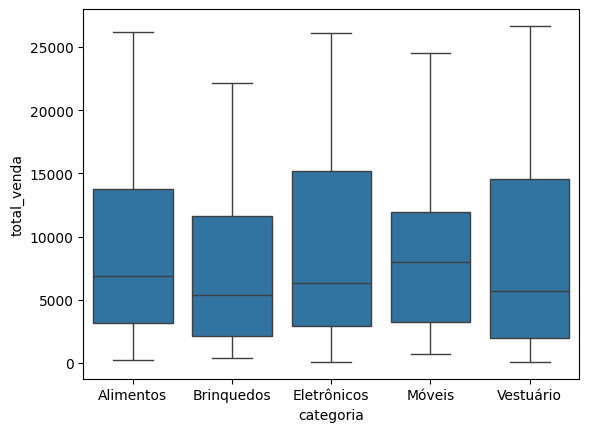

In [59]:
#boxploat por total de vendas por categoria
sns.boxplot(x='categoria', y='total_venda', data=df)
plt.show()

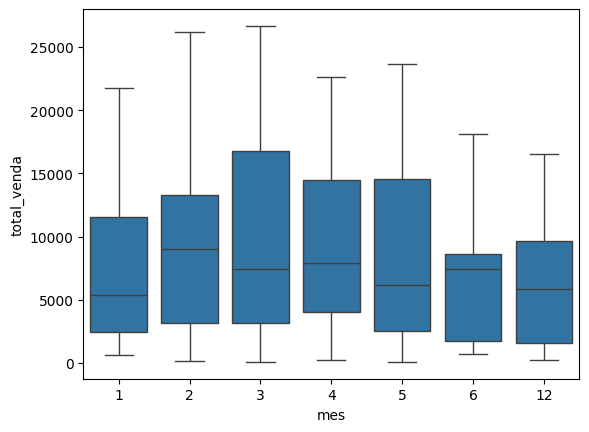

In [61]:
#boxploat por total de vendas por mes
sns.boxplot(x='mes', y='total_venda', data=df)
plt.show()

In [62]:
#comparando o ticket medio de vendas entre vip e não vip
print(df.groupby('STATUS')['total_venda'].mean())

STATUS
NÃO VIP     534.383333
VIP        9191.815824
Name: total_venda, dtype: float64


In [63]:
#comparando o valor total vendido por status
print(df.groupby('STATUS')['total_venda'].sum())

STATUS
NÃO VIP       9618.90
VIP        1672910.48
Name: total_venda, dtype: float64


In [64]:
#comparando a compra dos vip e não vip por categoria
print(df.groupby(['STATUS', 'categoria'])['total_venda'].sum())

STATUS   categoria  
NÃO VIP  Alimentos        1225.15
         Brinquedos       2359.33
         Eletrônicos      2610.03
         Móveis           1533.56
         Vestuário        1890.83
VIP      Alimentos      377552.12
         Brinquedos     328646.74
         Eletrônicos    319607.57
         Móveis         285319.85
         Vestuário      361784.20
Name: total_venda, dtype: float64
